In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib .pyplot
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import plot_model
from glob import glob


In [ ]:
import os
file_path = "Downloads/archive (3).zip"
print(os.path.exists(file_path))

True


In [ ]:
import zipfile

# Path to your ZIP file
zip_path = "Downloads/archive (3).zip"

# Specify the extraction directory
extract_to = "dataset_folder3"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Dataset extracted to {extract_to}")

Dataset extracted to dataset_folder3


In [ ]:
train_path = "dataset_folder2/DATASET/DATASET/TRAIN"
test_path = "dataset_folder2/DATASET/DATASET/TEST"

In [ ]:
import pandas as pd
import cv2
from tqdm import tqdm
from cv2 import cvtColor
train_path = r"dataset_folder3/DATASET/DATASET/TRAIN"

x_data = []
y_data = []

# Loop over the subdirectories in the extracted folder
for category in os.listdir(train_path):
    category_path = os.path.join(train_path, category)
    if os.path.isdir(category_path):
        for file in tqdm(os.listdir(category_path)):
            file_path = os.path.join(category_path, file)
            img_array = cv2.imread(file_path)
            if img_array is None:
                print(f"Error reading image: {file_path}")
                continue
            img_array = cvtColor(img_array, cv2.COLOR_BGR2RGB)  # RGB image color format
            x_data.append(img_array)
            y_data.append(category)

# a DataFrame to store the images and labels
data = pd.DataFrame({'image': x_data, 'label': y_data})

# Print the DataFrame head to check
print(data.head())

# Print total number of images and categories
print(f"\nTotal images loaded: {len(x_data)}")
print(f"Total categories found: {len(set(y_data))}")

100%|██████████| 9999/9999 [02:11<00:00, 76.17it/s]


                                               image label
0  [[[255, 255, 255], [255, 255, 255], [255, 255,...     O
1  [[[241, 242, 247], [241, 242, 247], [241, 242,...     O
2  [[[224, 224, 224], [229, 229, 229], [236, 236,...     O
3  [[[255, 255, 255], [255, 255, 255], [255, 255,...     O
4  [[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...     O

Total images loaded: 22564
Total categories found: 2


In [ ]:
import os

# the extracted directory and print the paths of .jpg files
for root, dirs, files in os.walk("dataset_folder3"):
    # Filter out .jpg files
    jpg_files = [file for file in files if file.endswith('.jpg')]
    if jpg_files:  # print if there are .jpg files
        print(f"Root: {root}")
        print(f"JPG Files: {jpg_files}")

Root: dataset_folder3\DATASET\DATASET\TEST\O
JPG Files: ['O_12568.jpg', 'O_12569.jpg', 'O_12570.jpg', 'O_12571.jpg', 'O_12572.jpg', 'O_12573.jpg', 'O_12574.jpg', 'O_12575.jpg', 'O_12576.jpg', 'O_12577.jpg', 'O_12578.jpg', 'O_12579.jpg', 'O_12580.jpg', 'O_12581.jpg', 'O_12582.jpg', 'O_12583.jpg', 'O_12584.jpg', 'O_12585.jpg', 'O_12586.jpg', 'O_12587.jpg', 'O_12588.jpg', 'O_12589.jpg', 'O_12590.jpg', 'O_12591.jpg', 'O_12592.jpg', 'O_12593.jpg', 'O_12594.jpg', 'O_12595.jpg', 'O_12596.jpg', 'O_12597.jpg', 'O_12598.jpg', 'O_12599.jpg', 'O_12600.jpg', 'O_12601.jpg', 'O_12602.jpg', 'O_12603.jpg', 'O_12604.jpg', 'O_12605.jpg', 'O_12606.jpg', 'O_12607.jpg', 'O_12608.jpg', 'O_12609.jpg', 'O_12610.jpg', 'O_12611.jpg', 'O_12612.jpg', 'O_12613.jpg', 'O_12614.jpg', 'O_12615.jpg', 'O_12616.jpg', 'O_12617.jpg', 'O_12618.jpg', 'O_12619.jpg', 'O_12620.jpg', 'O_12621.jpg', 'O_12622.jpg', 'O_12623.jpg', 'O_12624.jpg', 'O_12625.jpg', 'O_12626.jpg', 'O_12627.jpg', 'O_12628.jpg', 'O_12629.jpg', 'O_12630.jpg'

In [ ]:
print(x_data[0].shape)

(242, 208, 3)


In [ ]:
# PIE-PLOT OF RECYCLABLE AND ORGANIC

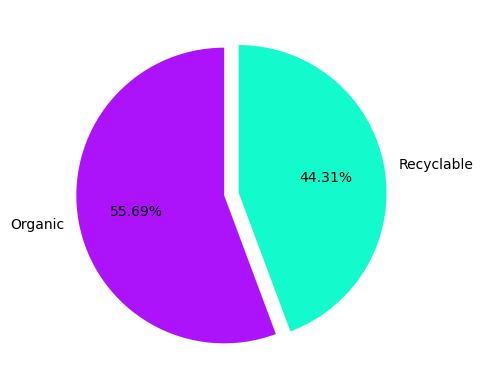

In [ ]:
colors = ['#ac13fa', '#13facc']
plt.pie(data.label.value_counts(),labels=['Organic','Recyclable'],autopct = '%0.2f%%',colors = colors, startangle =90, explode =[0.05,0.05])
plt.show()

In [ ]:
# .JPG IMAGES OF DATASETS INTO RECYLABLE AND ORGANIC

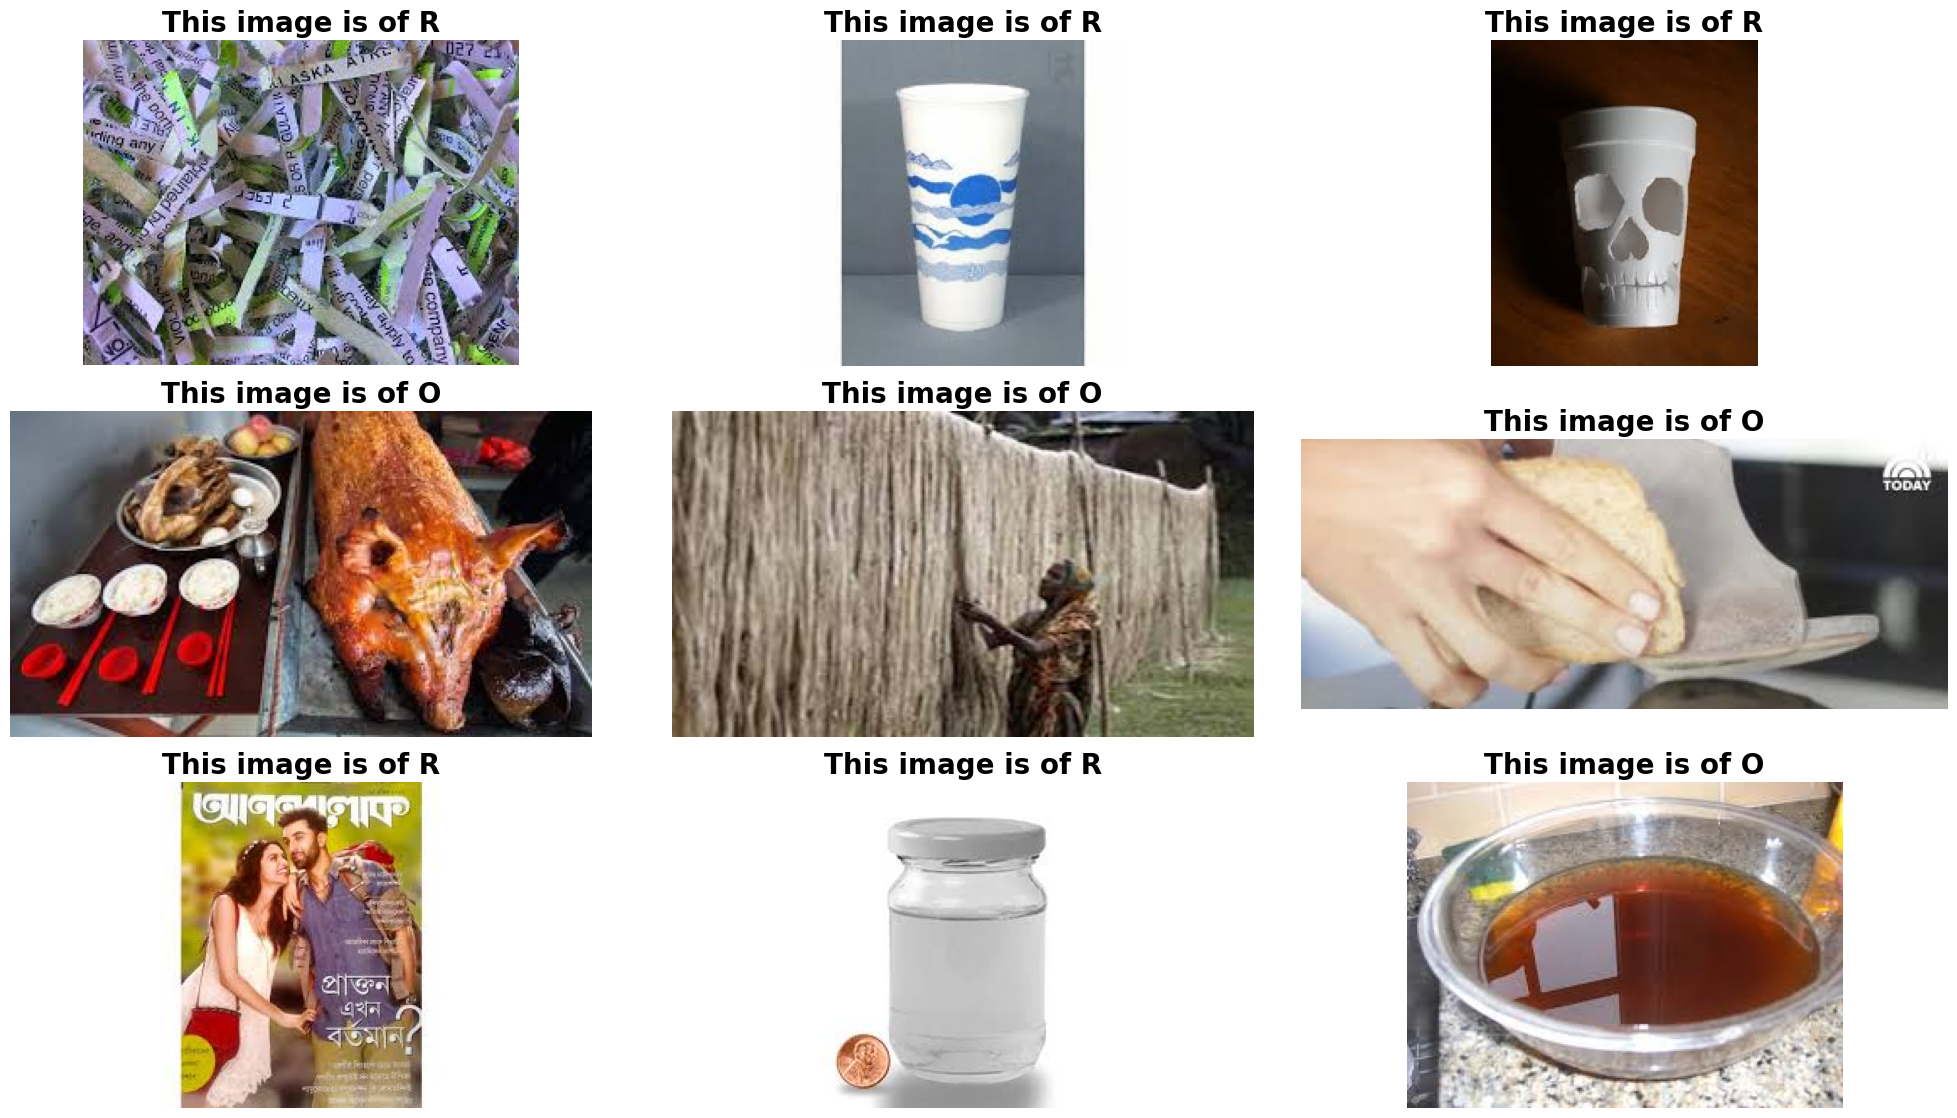

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))

# Display 9 random images
for i in range(9):
    plt.subplot(4, 3, i + 1)
    index = np.random.randint(len(data))  # Random index from the DataFrame size
    plt.title(f'This image is of {data.label[index]}', fontdict={'size': 20, 'weight': 'bold'})
    plt.imshow(data.image[index])
    plt.axis('off')  # Optionally hide axes for better image visibility
    plt.tight_layout()

plt.show()

In [ ]:
from glob import glob

train_path = "dataset_folder2/DATASET/DATASET/TRAIN"

# Use glob to get all subdirectories
className = glob(train_path + '/*')
numberOfClass = len(className)

print("Number Of Class:", numberOfClass)

Number Of Class: 2


In [ ]:
## CNN-MODEL ARCHITECTURE AND CNN-MODEL COMPILATION

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(224, 224, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(256))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(64))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(1))  # Single output neuron for binary classification
model.add(Activation("sigmoid"))  # Sigmoid for binary classification

model.compile(loss="binary_crossentropy",  # Binary crossentropy for two classes (MODEL-COMPILE)
              optimizer=Adam(),  # Adam optimizer
              metrics=["accuracy"])

batch_size = 256

In [ ]:
#DATA-AUGMENTATION

In [ ]:
train_datagen = ImageDataGenerator(rescale= 1./255)

In [ ]:
test_datagen = ImageDataGenerator(rescale= 1./255)

In [ ]:
import os

# Check if the train and test paths are correct
print("Train path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))

Train path exists: True
Test path exists: True


In [ ]:
#DATA PRE-PROCESSING FOR TRAINING

In [ ]:
# Training data generator for binary classification
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=batch_size,
    color_mode="rgb",  # RGB images
    class_mode="binary",  # Binary classification (0 or 1)
    shuffle=True  # Shuffle training data
)

# Test data generator for binary classification
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=batch_size,
    color_mode="rgb",  # RGB images
    class_mode="binary",  # Binary classification (0 or 1)
    shuffle=False  # Don't shuffle test data
)

Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [ ]:
##CNN-MODEL TRAINING

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitors validation loss
    patience=3,  # Number of epochs to wait for improvement
    restore_best_weights=True  # Restore the best weights when training stops
)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size,
    callbacks=[early_stopping]  # Use early stopping
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 580s 6s/step - accuracy: 0.6927 - loss: 0.7922 - val_accuracy: 0.8490 - val_loss: 0.3656
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.8516 - loss: 0.3818 - val_accuracy: 0.8763 - val_loss: 0.3370
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 506s 6s/step - accuracy: 0.8175 - loss: 0.4252 - val_accuracy: 0.8116 - val_loss: 0.4315
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.8242 - loss: 0.4483 - val_accuracy: 0.7904 - val_loss: 0.4395
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 605s 7s/step - accuracy: 0.8321 - loss: 0.3962 - val_accuracy: 0.8702 - val_loss: 0.3100
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 205ms/step - accuracy: 0.8633 - loss: 0.3098 - val_accuracy: 0.8806 - val_loss: 0.3096
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 561s 6s/step - accuracy: 0.8573 - loss: 0.3473 - val_accuracy: 0.9041 - val_loss: 0.2561
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 178ms/step - accuracy: 0.8672 - loss: 0.3562 - val_accuracy: 0.

In [ ]:
# Evaluate the model on the test (validation) set
test_loss, test_accuracy = model.evaluate(test_generator)

# Print the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9428 - loss: 0.1769
Test Loss: 0.2737
Test Accuracy: 0.8926


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,  # Number of epochs to wait for improvement
    restore_best_weights=True  # Restore the best weights when training stops
)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size,
    callbacks=[early_stopping]  # Use early stopping
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 516s 6s/step - accuracy: 0.8667 - loss: 0.3262 - val_accuracy: 0.8885 - val_loss: 0.2854
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.8672 - loss: 0.3165 - val_accuracy: 0.8832 - val_loss: 0.2933
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 532s 6s/step - accuracy: 0.8813 - loss: 0.2983 - val_accuracy: 0.9023 - val_loss: 0.2480
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.8633 - loss: 0.3127 - val_accuracy: 0.9084 - val_loss: 0.2418
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 505s 6s/step - accuracy: 0.8857 - loss: 0.2860 - val_accuracy: 0.8893 - val_loss: 0.2883
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.8984 - loss: 0.2851 - val_accuracy: 0.8924 - val_loss: 0.2741
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 515s 6s/step - accuracy: 0.9050 - loss: 0.2420 - val_accuracy: 0.9171 - val_loss: 0.2506


In [ ]:
# Evaluate the model on the test (validation) set
test_loss, test_accuracy = model.evaluate(test_generator)

# Print the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9387 - loss: 0.1896
Test Loss: 0.2511
Test Accuracy: 0.9021


In [ ]:
#MODEL EVALUATION USING METRICS LIKE PRECISION,CONFUSION-MATRIX,RECALL,AUC-CURVE

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get the true labels and predictions
test_labels = test_generator.classes  # True labels
test_predictions = model.predict(test_generator, verbose=1)  # Predicted labels

# Convert predictions to binary (threshold at 0.5 for sigmoid output)
test_predictions = np.where(test_predictions > 0.5, 1, 0)

# Print classification report (precision, recall, f1-score)
print(classification_report(test_labels, test_predictions))

# Alternatively, calculate confusion matrix
conf_matrix = confusion_matrix(test_labels, test_predictions)
print("Confusion Matrix:\n", conf_matrix)

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1401
           1       0.92      0.85      0.88      1112

    accuracy                           0.90      2513
   macro avg       0.91      0.90      0.90      2513
weighted avg       0.90      0.90      0.90      2513

Confusion Matrix:
 [[1323   78]
 [ 168  944]]


In [ ]:
y_true = test_generator.classes

In [ ]:
y_pred = model.predict(test_generator, verbose=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


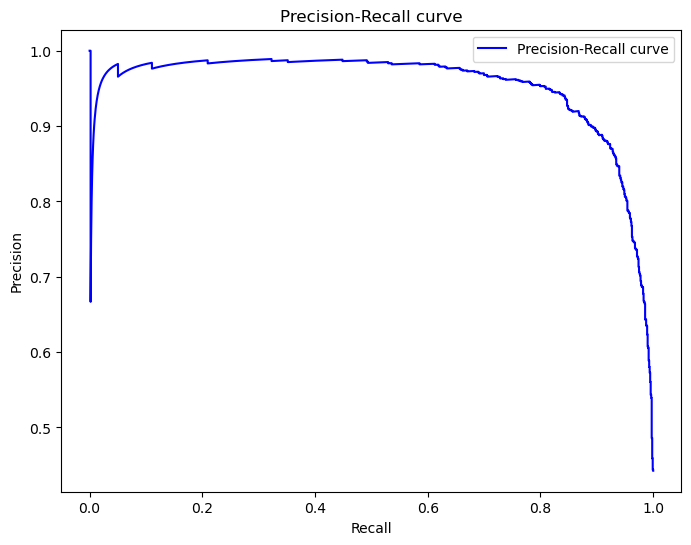

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(y_true, y_pred)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()

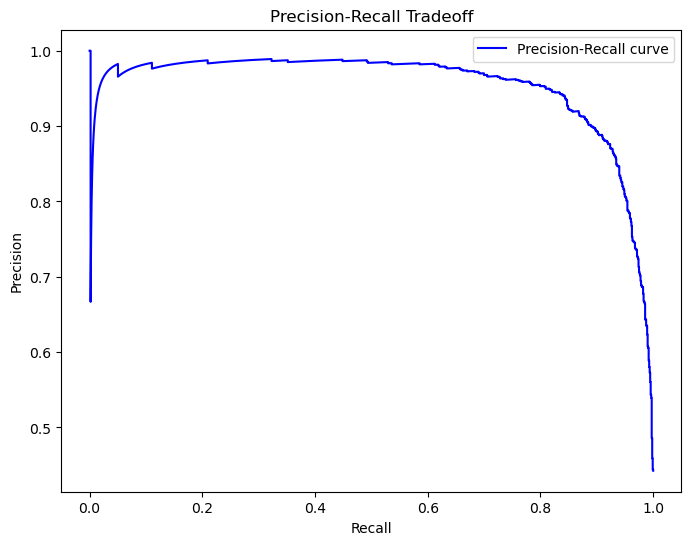

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# CALCULATE PRECISION-RECALL
precision, recall, thresholds = precision_recall_curve(y_true, y_pred)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Tradeoff')
plt.legend()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


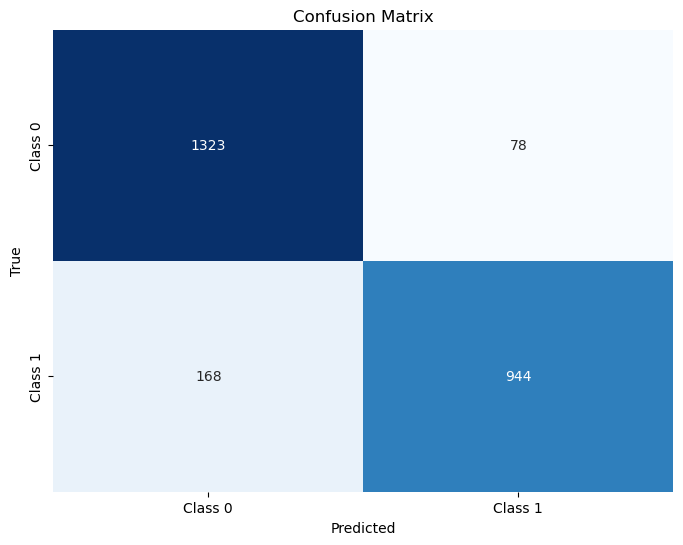

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_true is true labels and y_pred is predicted labels
# These will be the ground truth and model predictions from evaluation or test set


y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)  #  binary labels (0 or 1)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

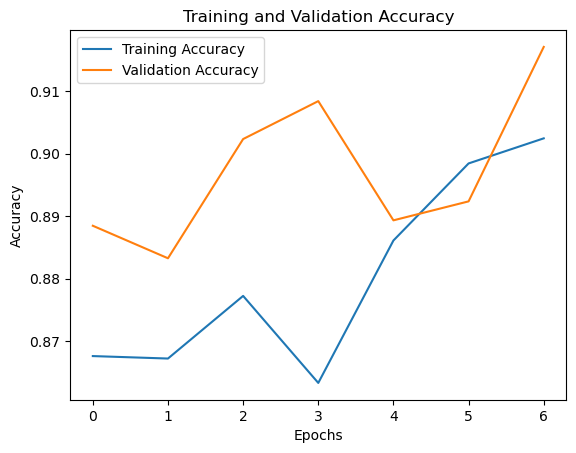

In [ ]:
import matplotlib.pyplot as plt
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Add labels and title
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

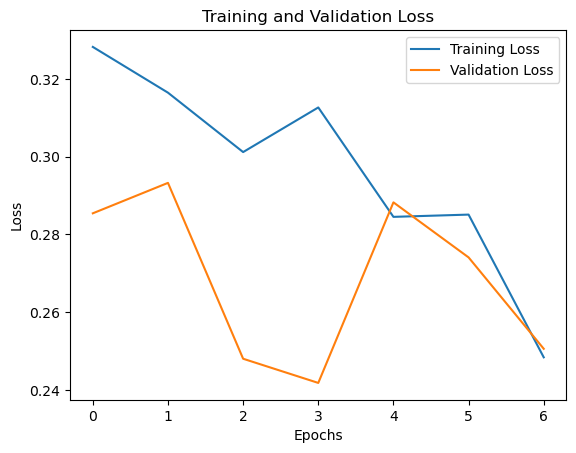

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# labels and title
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

# Getting true labels for the validation set
val_labels = test_generator.classes  # Assuming test_generator is validation generator

# Get predicted probabilities for the validation set
val_predictions = model.predict(test_generator)  # Model's predictions (probabilities)

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(val_labels, val_predictions)

# Calculate AUC for Precision-Recall curve
auc_score = auc(recall, precision)
print("AUC-PR:", auc_score)

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
AUC-PR: 0.9529342048701382


10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


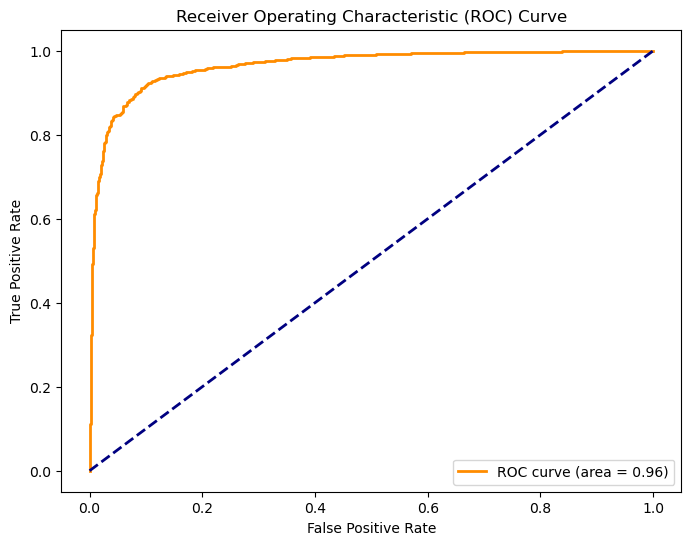

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Getting the predictions for the test set (probabilities)
test_predictions = model.predict(test_generator)

# True labels for the test set
true_labels = test_generator.classes

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_labels, test_predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


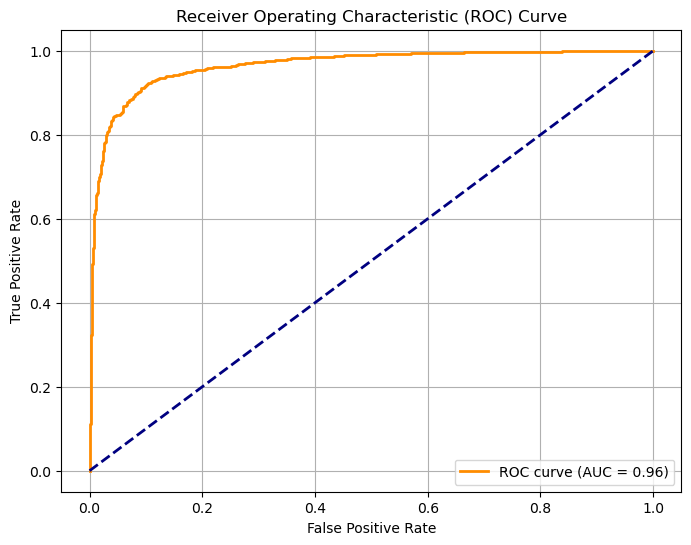

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# the predictions for the test set (probabilities)
test_predictions = model.predict(test_generator)
test_predictions = test_predictions.ravel()

# True labels for the test set
true_labels = test_generator.classes

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(true_labels, test_predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91      1401
           1       0.92      0.85      0.88      1112

    accuracy                           0.90      2513
   macro avg       0.91      0.90      0.90      2513
weighted avg       0.90      0.90      0.90      2513



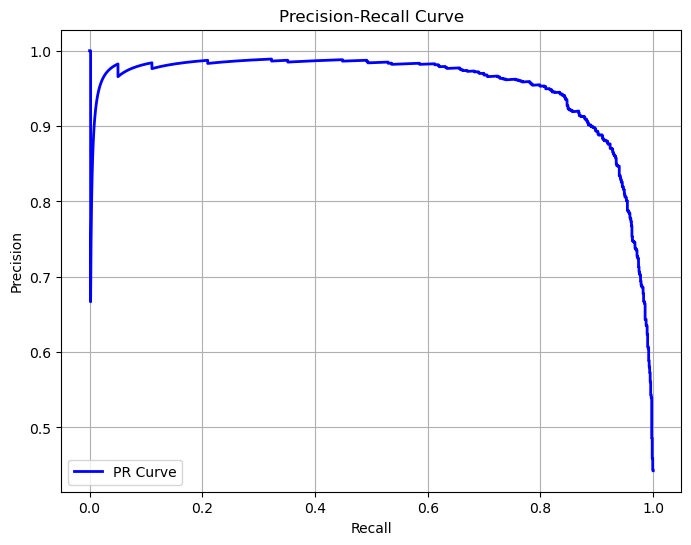

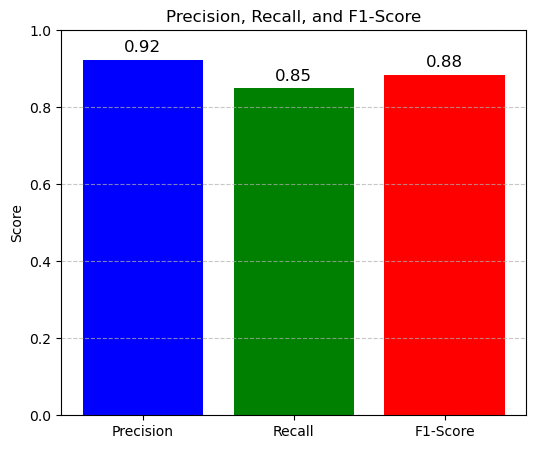

In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# the predicted probabilities for the test set
test_predictions = model.predict(test_generator).ravel()

# True labels
true_labels = test_generator.classes

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(true_labels, test_predictions)

# Compute F1-score
f1 = f1_score(true_labels, test_predictions.round())
precision_val = precision_score(true_labels, test_predictions.round())
recall_val = recall_score(true_labels, test_predictions.round())

# Print Classification Report
print("Classification Report:\n", classification_report(true_labels, test_predictions.round()))

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()
plt.show()

# Bar Chart for Precision, Recall, and F1-score
metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision_val, recall_val, f1]

plt.figure(figsize=(6, 5))
plt.bar(metrics, values, color=['blue', 'green', 'red'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show values on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)

plt.show()

In [ ]:
##TESTING UNSEEN IMAGES IN CNN-MODEL

In [ ]:
def predict_func(img):
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    img = cv2.resize(img, (224, 224))
    img = np.reshape(img, [-1, 224, 224,3])
    result = np.argmax(model.predict(img))
    if result == 0: print("\033[94m"+"This image -> Recyclable"+"\033[0m")
    elif result ==1: print("\033[94m"+"This image -> Organic"+"\033[0m")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
This image -> Recyclable
Raw prediction: [0.13950984]


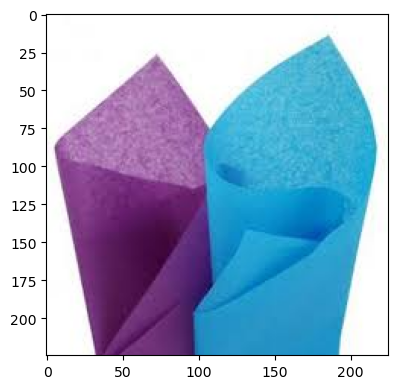

In [ ]:
test_img = cv2.imread("dataset_folder3/DATASET/DATASET/TEST/R/R_10753.jpg")
predict_func(test_img)

In [ ]:
def predict_func(img):
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.tight_layout()

    # Resize and preprocess the image
    img = cv2.resize(img, (224, 224))
    img = np.reshape(img, [-1, 224, 224, 3])

    # Normalize the image
    img = img / 255.0  # Normalize pixel values

    # Make prediction
    prediction = model.predict(img)

    # If using a threshold of 0.5 for binary classification
    if prediction[0] > 0.5:
        print("\033[94m"+"This image -> Organic"+"\033[0m")
    else:
        print("\033[94m"+"This image -> Recyclable"+"\033[0m")

    # Optionally, display the raw prediction (probability)
    print(f"Raw prediction: {prediction[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
This image -> Organic
Raw prediction: [0.88319623]


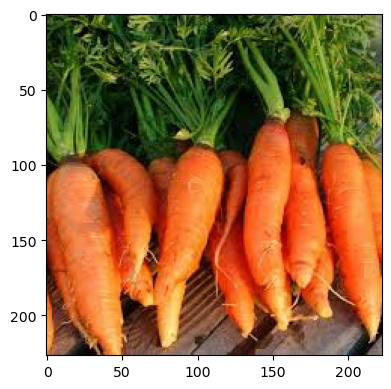

In [ ]:
test_img = cv2.imread("dataset_folder3/DATASET/DATASET/TEST/O/O_12568.jpg")
predict_func(test_img)

In [ ]:
#SAVING PRE-PROCESSING PIPELINE CNN-MODEL AS 'traintest11_CNN1.KERAS' TO LOAD MODEL

In [ ]:
model.save('traintest11_CNN1.keras')